# AIVLE스쿨 1차 미니프로젝트: 서울시 생활정보 기반 대중교통 수요 분석

<img src = "https://github.com/Jangrae/img/blob/master/bus.png?raw=true" width=800, align="left"/>

- 본 과정에서는 서울시 생활정보 데이터를 기반으로 데이터 분석을 시도하고 주어진 문제를 해결할 것입니다.
- 우리는 공공 데이터를 활용해 버스노선 관련 인사이트를 도출하여 유용한 정책을 세우는데 도움을 주고자 합니다.

### 로컬 수행(Anaconda)
- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [1]:
# 기본 경로
path = ''

### 구글 콜랩 수행

- 구글 콜랩을 사용중이면 구글 드라이브를 연결합니다.

In [2]:
# 구글 드라이브 연결, 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project/'

### 한글 폰트 표시를 위해 설치합니다.

In [3]:
# 한글 표시를 위한 라이브러리 설치
!pip install koreanize_matplotlib -q

### 필요한 라이브러리를 불러옵니다.

In [4]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import scipy.stats as spst
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

## ▣ 우리가 풀어야 하는 문제는 무엇인가요?

- 제공 데이터
    - 버스 승하차 및 운행 노선 데이터
    - 구별 유동인구 데이터
    - 구별 주민 등록 데이터
    - 구별 업종 등록 정보
    
#### 위 제공 데이터를 분석하여 버스 노선 추가 필요 대상 지역(구 단위)을 선정합니다.

# 1. 데이터 불러오기

- 이전 과정에서 저장한 다음 4개의 파일을 불러와 데이터프레임으로 선언합니다.
    - 구별 버스 정류장 데이터(df_seoul_bus_station.csv) → df_seoul_bus_station
    - 구별 유동인구 데이터(df_seoul_moving.csv) → df_seoul_moving
    - 구별 상권 데이터(df_seoul_business.csv) → df_seoul_business
    - 구별 인구 데이터(df_seoul_people.csv) → df_seoul_people

In [5]:
# 구별 버스 정류장 데이터불러오기
df_seoul_bus_station = pd.read_csv(path + 'df_seoul_bus_station.csv')

# 확인
df_seoul_bus_station.head()

,자치구,정류장수,노선수,승차총승객수,하차총승객수,승차평균승객수,하차평균승객수
0,강남구,502,99,9113021,8640353,135.163908,128.153318
1,강동구,376,24,3306588,3242901,94.638885,92.816079
2,강북구,410,71,5244436,5077041,138.244306,133.831743
3,강서구,565,54,5244615,5218001,93.106837,92.634362
4,관악구,465,82,7691243,7850254,147.777793,150.832994


In [6]:
# 구별 유동인구 데이터 불러오기
df_seoul_moving = pd.read_csv(path + 'df_seoul_moving.csv')

# 확인
df_seoul_moving.head()

,자치구,평균 이동 시간(분),이동인구(합),총 이동 시간,총 이동인구
0,강남구,65.220874,89.880083,37563832,51766253.76
1,강동구,71.135695,67.088111,27212889,25664489.79
2,강북구,65.258796,38.290780,24201877,14200518.80
3,강서구,70.107829,59.547527,30772920,26137612.75
4,관악구,63.064536,47.985346,27629141,21022812.01


In [7]:
#  구별 상권 데이터 불러오기
df_seoul_business = pd.read_csv(path + 'df_seoul_business.csv')

# 확인
df_seoul_business.head()

,자치구,택시운송업,한식 일반 음식점업,용달 화물자동차 운송업,부동산 중개 및 대리업,두발미용업,커피전문점,남녀용 겉옷 및 셔츠 도매업,기타주점업,일반 교과 학원,한식 육류요리 전문점
0,종로구,215,5912,646,889,480,3613,962,1413,382,1982
1,중구,235,6414,333,1152,816,3542,24248,982,175,2121
2,용산구,523,2987,466,1214,777,2076,317,1332,573,1184
3,성동구,2527,2785,1161,1453,851,1859,1572,621,1494,1545
4,광진구,1744,2861,985,1313,1337,1887,687,1577,1646,1678


In [8]:
# 구별 인구 데이터 불러오기
df_seoul_people = pd.read_csv(path + 'df_seoul_people.csv')

# 확인
df_seoul_people.head()

,자치구,남자,여자,합계
0,종로구,71654,78390,150044
1,중구,63365,68392,131757
2,용산구,105480,113343,218823
3,성동구,136779,146555,283334
4,광진구,166541,183141,349682


# 2. 데이터 합치기

- 위에서 선언한 네 개의 데이터프레임을 '자치구'열을 기준으로 조인(merge)합니다.
- 조인 결과를 df 데이터프레임으로 선언합니다.

In [9]:
# 네 개의 데이터프레임 조인(megre)
df = pd.merge(df_seoul_bus_station, df_seoul_moving, how='inner', on='자치구')
df = pd.merge(df, df_seoul_business, how='inner', on='자치구')
df = pd.merge(df, df_seoul_people, how='inner', on='자치구')

In [10]:
# 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   자치구              25 non-null     object 
 1   정류장수             25 non-null     int64  
 2   노선수              25 non-null     int64  
 3   승차총승객수           25 non-null     int64  
 4   하차총승객수           25 non-null     int64  
 5   승차평균승객수          25 non-null     float64
 6   하차평균승객수          25 non-null     float64
 7   평균 이동 시간(분)      25 non-null     float64
 8   이동인구(합)          25 non-null     float64
 9   총 이동 시간          25 non-null     int64  
 10  총 이동인구           25 non-null     float64
 11  택시운송업            25 non-null     int64  
 12  한식 일반 음식점업       25 non-null     int64  
 13  용달 화물자동차 운송업     25 non-null     int64  
 14  부동산 중개 및 대리업     25 non-null     int64  
 15  두발미용업            25 non-null     int64  
 16  커피전문점            25 non-null     int64  
 17  남녀용 겉옷 및 셔츠 도매업  2

# 3. 가설 수립 
$ \huge X \rightarrow Y $
- 가설을 수립해 보세요. (3개 이상)
- 미니프로젝트 진행의 편의상 가설은 이변량 분석을 염두에 두고 설정해 주세요.
- 다양한 가설이 가능하나, 프로젝트 주제에 맞게 '노선 수'에 대한 가설도 포함해 주세요.

### 1) 가설 1: 노선수는 [인구수, 승하차인구수, 음식점수]와 비례할 것이다.

### 2) 가설 2: 평균이동시간은 [노선수, 택시운송업수]와 상관관계가 있을 것이다. (노선수, 택시운송업 -> 평균이동시간)

# 4. 단변량 분석

- 변수의 비즈니스 의미  
- 숫자형, 범주형 구분  
- 전처리 사항
   - NaN 존재 여부 및 조치 방안  
   - 가변수화 대상여부  
- 기초통계량
- 분포  
- 위 정보로부터 파악한 내용(비즈니스) 정리  
- 추가 분석해볼 사항 도출 등

In [123]:
# 시각화 함수
def eda_1_num(data, var, bins = 30):

    # 기초통계량
    print('<< 기초통계량 >>')
    display(data[[var]].describe().T)
    print('=' * 100)

    # 시각화
    print('<< 그래프 >>')
    plt.figure(figsize = (5,3))

    plt.subplot(2,1,1)
    sns.histplot(data[var], bins = bins, kde = True)
    plt.grid()

    plt.subplot(2,1,2)
    sns.boxplot(x = data[var])
    plt.grid()
    plt.show()

### 1) 노선수는 [인구수, 승하차인구수, 음식점수] 와 비례할 것이다.

In [124]:
df_1 = df[['자치구', '노선수', '합계']]
df_1['승하차인구수'] = df['승차총승객수'] + df['하차총승객수']
df_1['음식점수'] = df['한식 일반 음식점업'] + df['커피전문점'] + df['기타주점업'] + df['한식 육류요리 전문점']
df_1.head()

,자치구,노선수,합계,승하차인구수,음식점수
0,강남구,99,562755,17753374,26295
1,강동구,24,467902,6549489,7856
2,강북구,71,289827,10321477,6209
3,강서구,54,564485,10462616,11097
4,관악구,82,497137,15541497,9038


In [125]:
print(df_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   자치구     25 non-null     object
 1   노선수     25 non-null     int64 
 2   합계      25 non-null     int64 
 3   승하차인구수  25 non-null     int64 
 4   음식점수    25 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.1+ KB
None


<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
노선수,25.0,75.84,23.487018,24.0,57.0,75.0,100.0,109.0


<< 그래프 >>


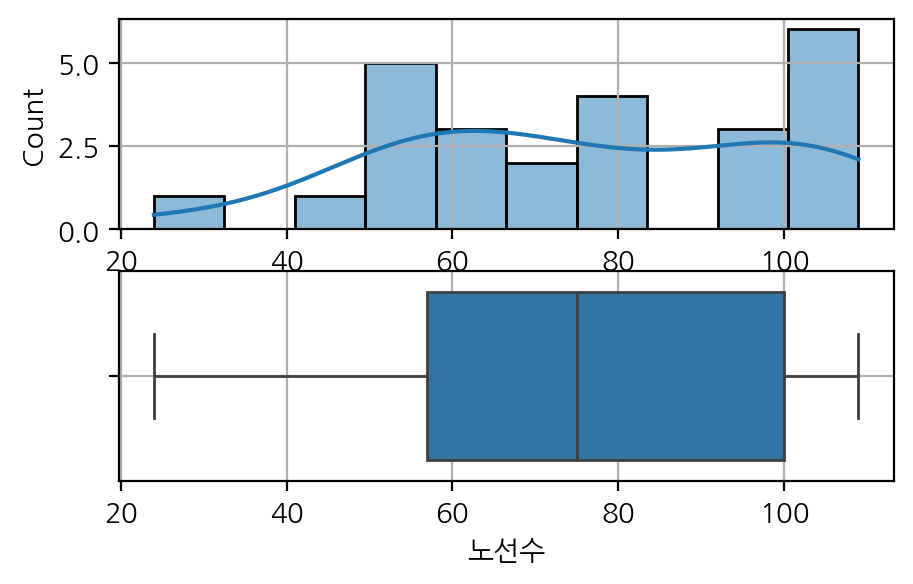

In [126]:
var = '노선수'
eda_1_num(df_1, var, bins = 10)

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
합계,25.0,384530.68,126587.549792,131757.0,307784.0,389003.0,467902.0,658360.0


<< 그래프 >>


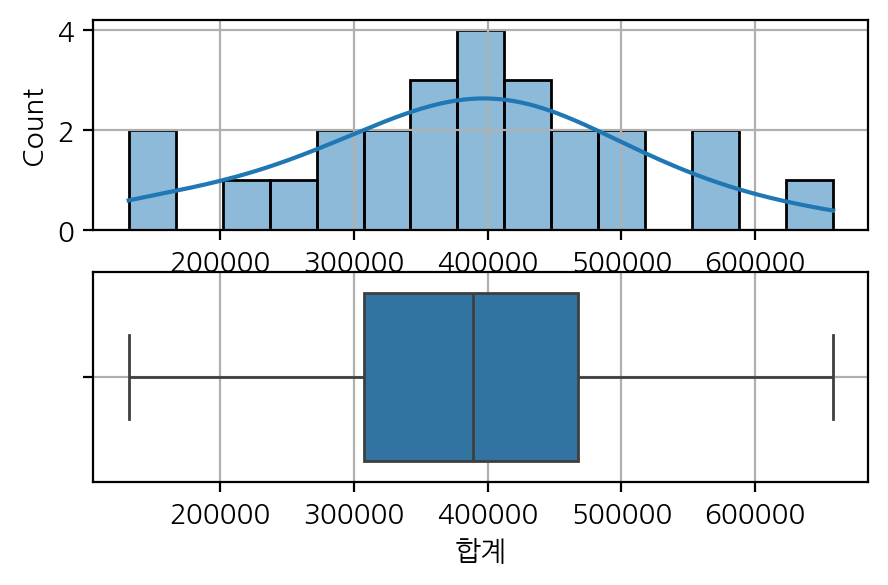

In [127]:
var = '합계'
eda_1_num(df_1, var, bins = 15)

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
승하차인구수,25.0,10740164.16,2.988618e+06,6319907.0,8623374.0,10775417.0,12349171.0,17753374.0


<< 그래프 >>


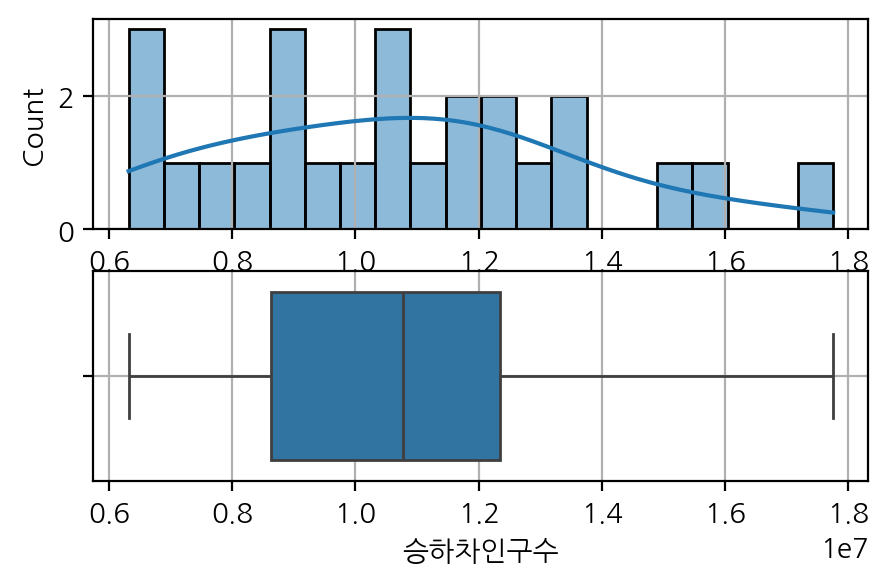

In [128]:
var = '승하차인구수'
eda_1_num(df_1, var, bins = 20)

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
음식점수,25.0,9341.16,4729.632083,4266.0,6232.0,7579.0,12920.0,26295.0


<< 그래프 >>


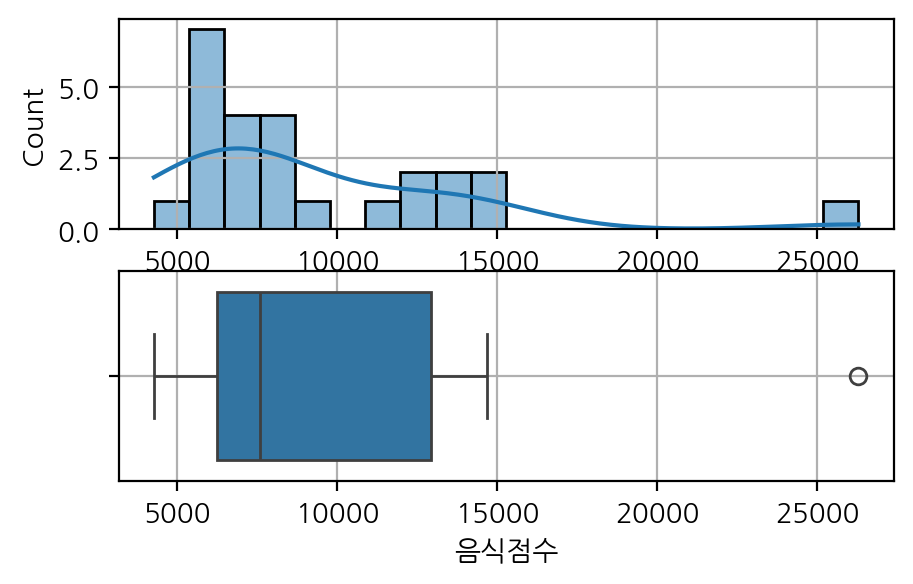

In [129]:
var = '음식점수'
eda_1_num(df_1, var, bins = 20)

### 2) 평균이동시간은 [노선수, 택시운송업수]와 상관관계가 있을 것이다. (노선수, 택시운송업 -> 평균이동시간)

In [154]:
# 데이터프레임 만들기
df_2 = df[['자치구', '평균 이동 시간(분)', '총 이동인구', '합계', '노선수','택시운송업']]
df_2.head()

,자치구,평균 이동 시간(분),총 이동인구,합계,노선수,택시운송업
0,강남구,65.220874,51766253.76,562755,99,2517
1,강동구,71.135695,25664489.79,467902,24,4980
2,강북구,65.258796,14200518.80,289827,71,2589
3,강서구,70.107829,26137612.75,564485,54,6922
4,관악구,63.064536,21022812.01,497137,82,2027


In [131]:
print(df_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   평균 이동 시간(분)  25 non-null     float64
 1   총 이동인구       25 non-null     float64
 2   합계           25 non-null     int64  
 3   노선수          25 non-null     int64  
 4   택시운송업        25 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 KB
None


<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
평균 이동 시간(분),25.0,62.947805,4.293887,56.495425,59.91723,62.8062,65.848807,71.135695


<< 그래프 >>


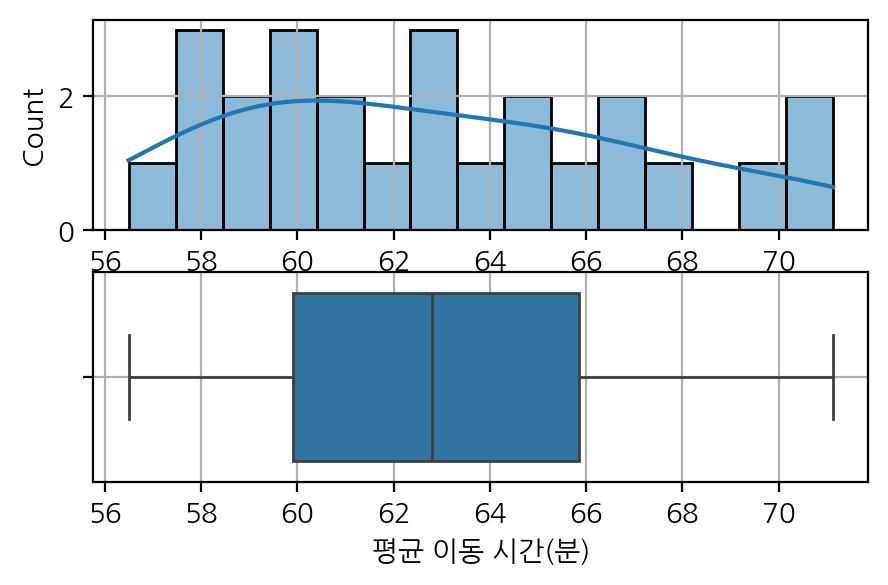

In [132]:
var = '평균 이동 시간(분)'
eda_1_num(df_2, var, bins = 15)

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
총 이동인구,25.0,2.219275e+07,8.977380e+06,9314767.58,17755257.26,19652113.55,25664489.79,51766253.76


<< 그래프 >>


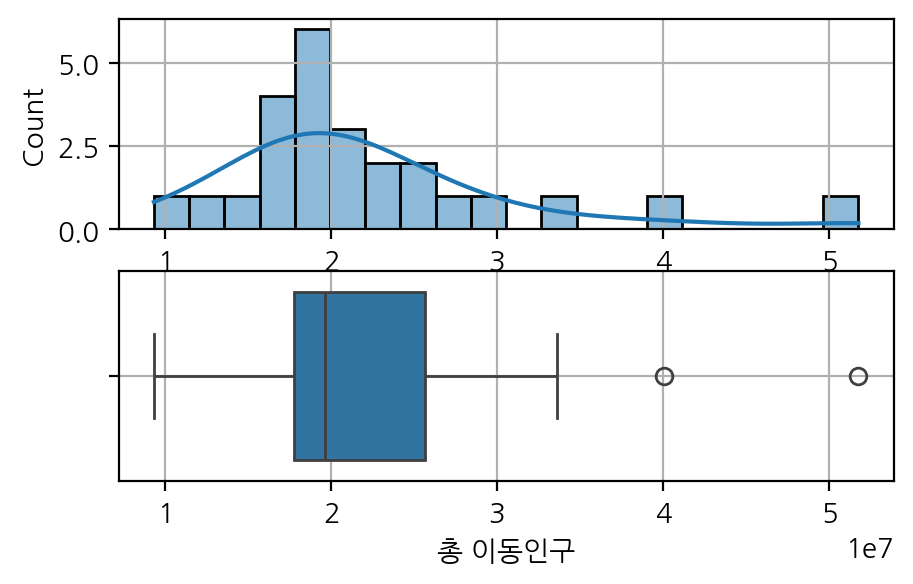

In [133]:
var = '총 이동인구'
eda_1_num(df_2, var, bins = 20)

<< 기초통계량 >>


,count,mean,std,min,25%,50%,75%,max
택시운송업,25.0,3068.04,1963.159772,215.0,1838.0,2589.0,4850.0,6922.0


<< 그래프 >>


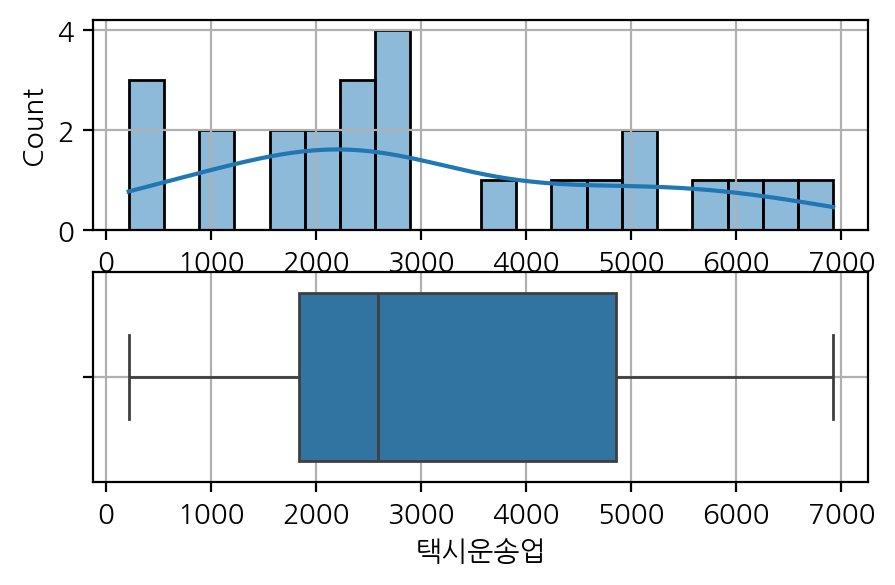

In [134]:
var = '택시운송업'
eda_1_num(df_2, var, bins = 20)

# 5.이변량 분석

- 자료 종류에 맞게 $X \rightarrow Y$ 에 대해서 그래프(시각화)와 가설검정(수치화)를 수행하고 결과를 평가하세요.
- 가설 검정 시 다음 항목을 참조하여 수행하세요.
    - 유의수준: 5%
    - 숫자 → 숫자: 상관분석
    - 범주 → 범주: 카이제곱검정
    - 범주 → 숫자: t검정, 분산분석
    - 숫자 → 범주: 로지스틱 회귀모형을 통해, 회귀계수의 p-value로 검정을 수행합니다.

### 상관계수 (우리가 배운 기준)

- 0.5 ~ 1: 강한
- 0.2 ~ 0.5: 중간
- 0.1 ~ 0.2: 약간
- 0 ~ 0.1: 없음
- 음수 똑같음 

### p-value 기준: 0.05 (5%)

- p-value가 0.05보다 크다 => 귀무가설을 기각 하지 못한다 => 대립가설(우리가 원하는 바)이 틀렸다
- 귀무가설을 기각하려면 우리가 싫어하는 귀무가설을 입증할 증거가 나올 확률이 5% 이하여야 함
- p-value가 그 귀무가설을 입증할 증거가 나올 확률을 의미함

### 1) 노선수는 [인구수, 승하차인구수, 음식점수] 와 비례할 것이다.

In [138]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   자치구     25 non-null     object
 1   노선수     25 non-null     int64 
 2   합계      25 non-null     int64 
 3   승하차인구수  25 non-null     int64 
 4   음식점수    25 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.1+ KB


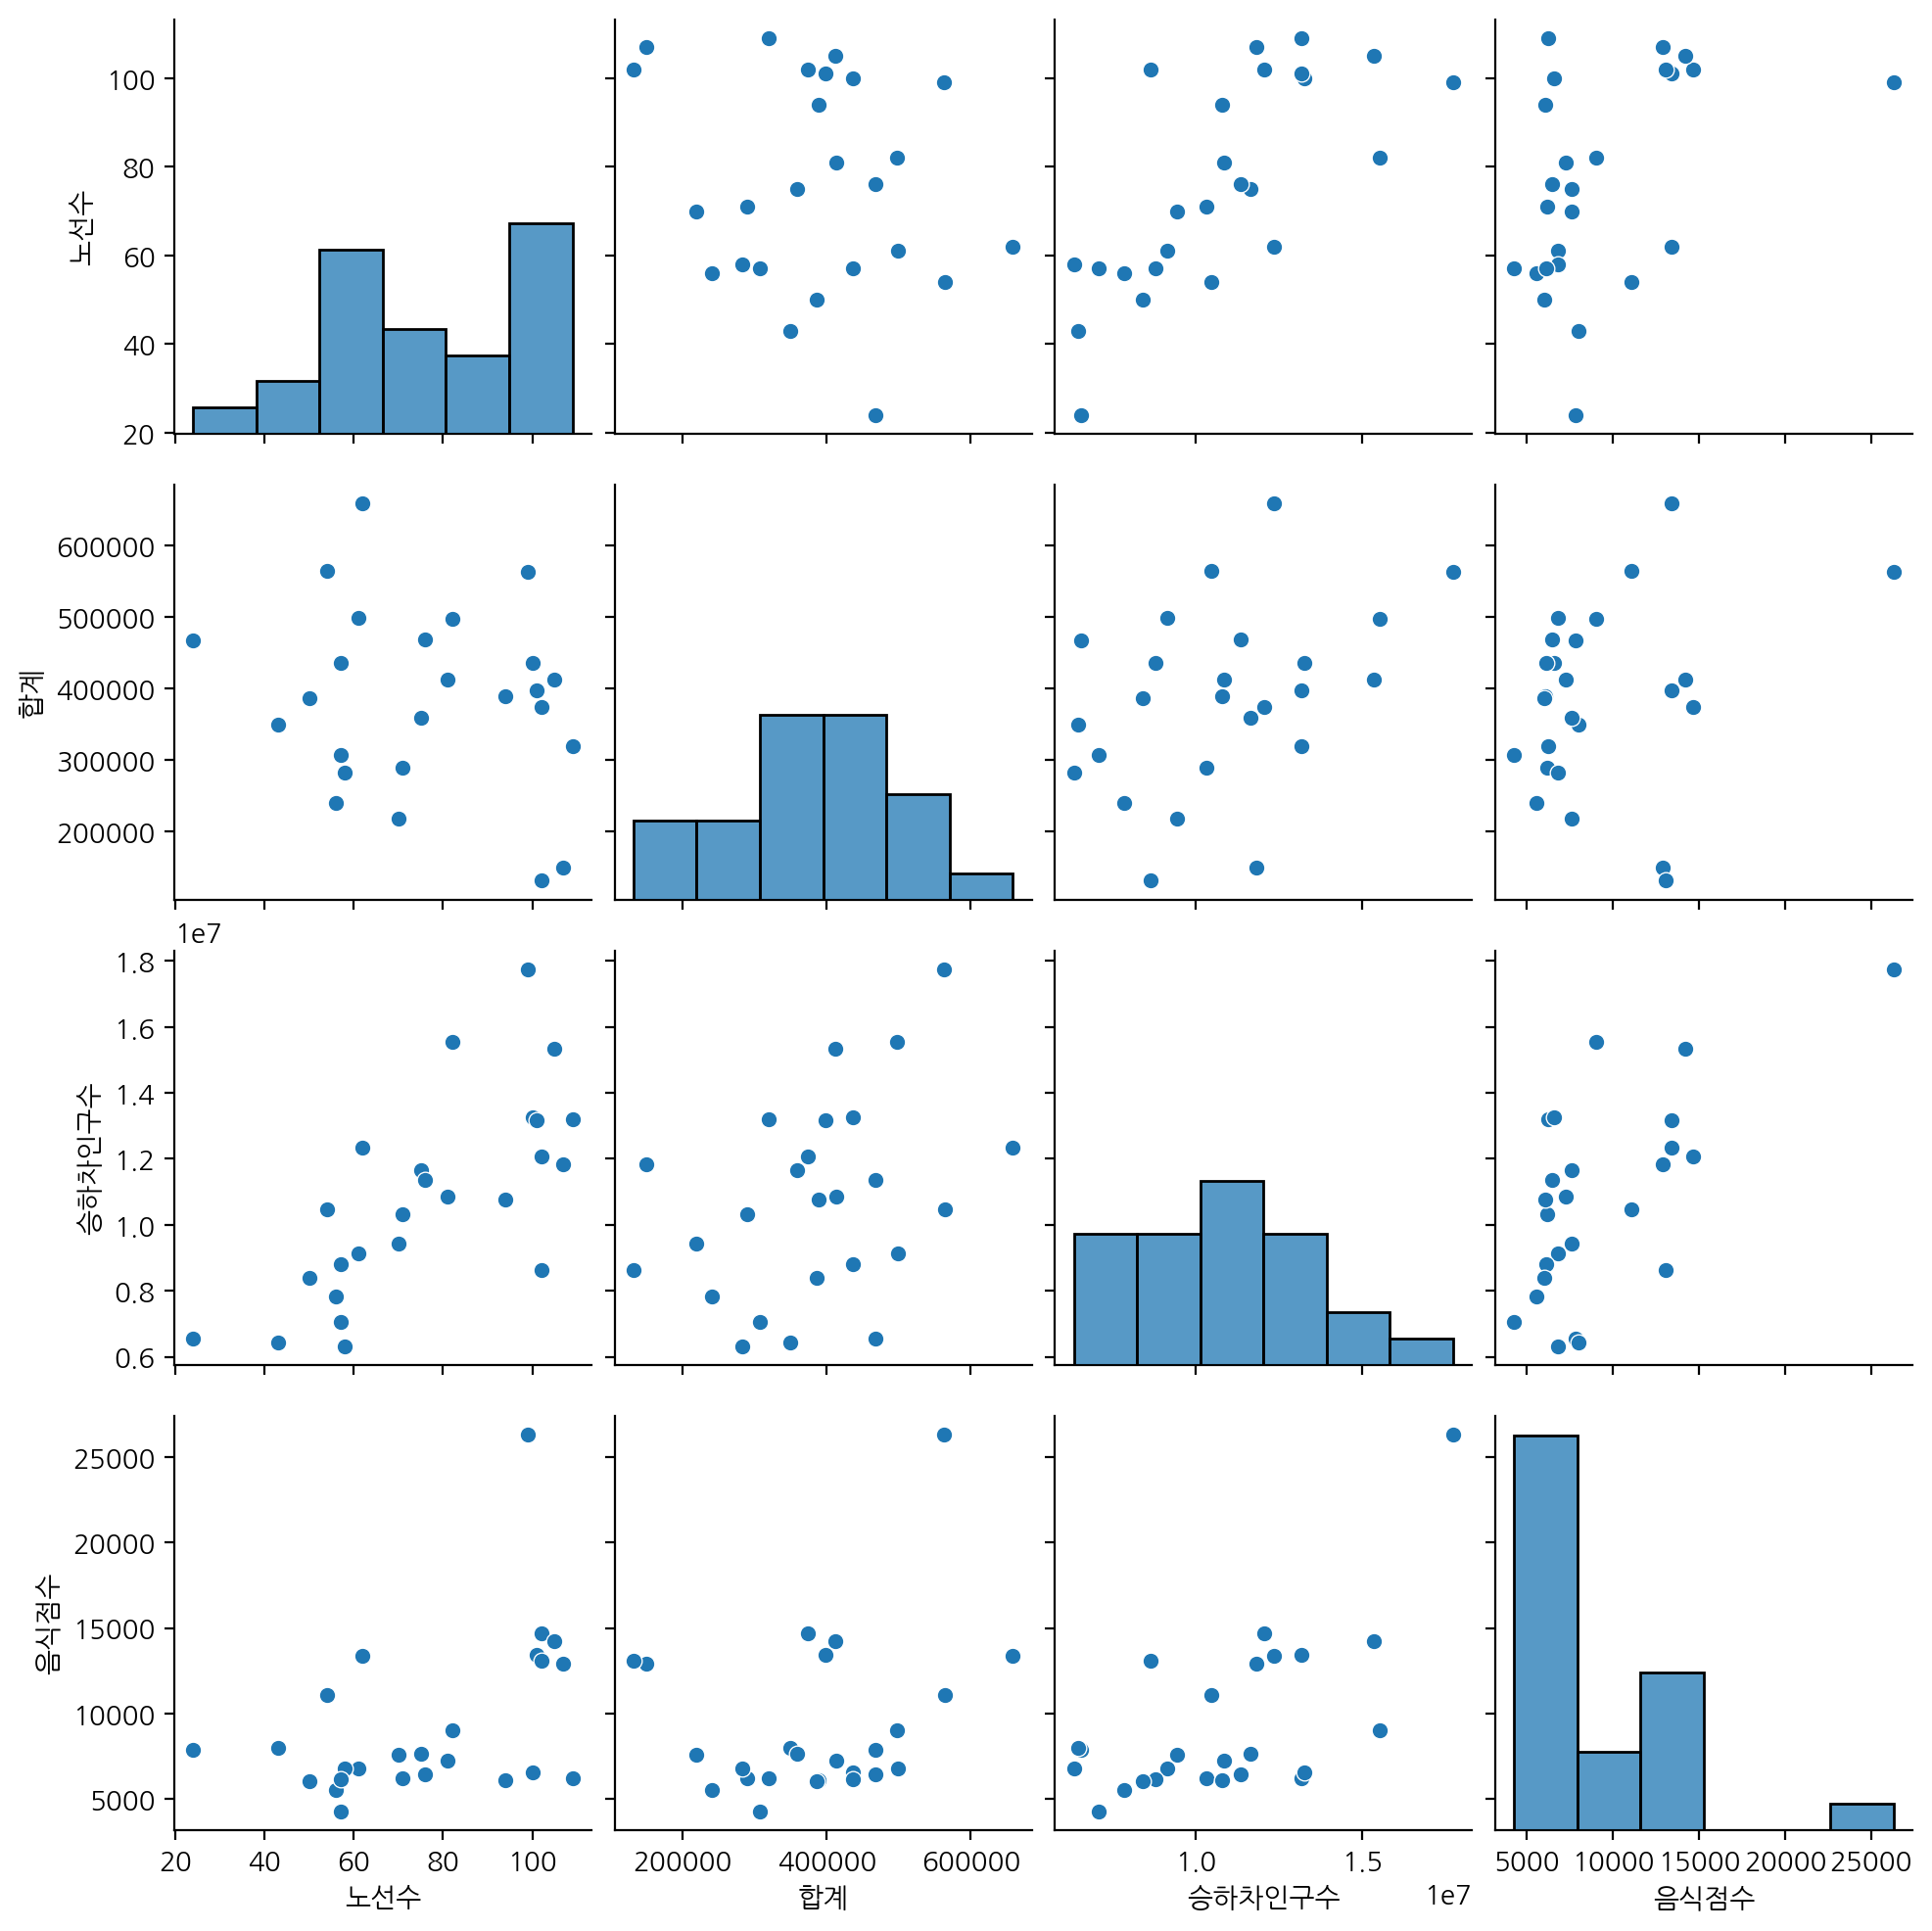

In [139]:
# 시각화
sns.pairplot(df_1)
plt.show()

In [140]:
df_1.corr(numeric_only=True)

,노선수,합계,승하차인구수,음식점수
노선수,1.000000,-0.209958,0.725374,0.448536
합계,-0.209958,1.000000,0.388562,0.263510
승하차인구수,0.725374,0.388562,1.000000,0.633905
음식점수,0.448536,0.263510,0.633905,1.000000


In [141]:
# 상관계수와 p-value
import scipy.stats as spst
print(spst.pearsonr(df_1['노선수'], df_1['합계']))
print(spst.pearsonr(df_1['노선수'], df_1['승하차인구수']))
print(spst.pearsonr(df_1['노선수'], df_1['음식점수']))

PearsonRResult(statistic=-0.20995834421299847, pvalue=0.31377533226772575)
PearsonRResult(statistic=0.7253742881923433, pvalue=4.082771066455278e-05)
PearsonRResult(statistic=0.44853646321280294, pvalue=0.024520622383656248)


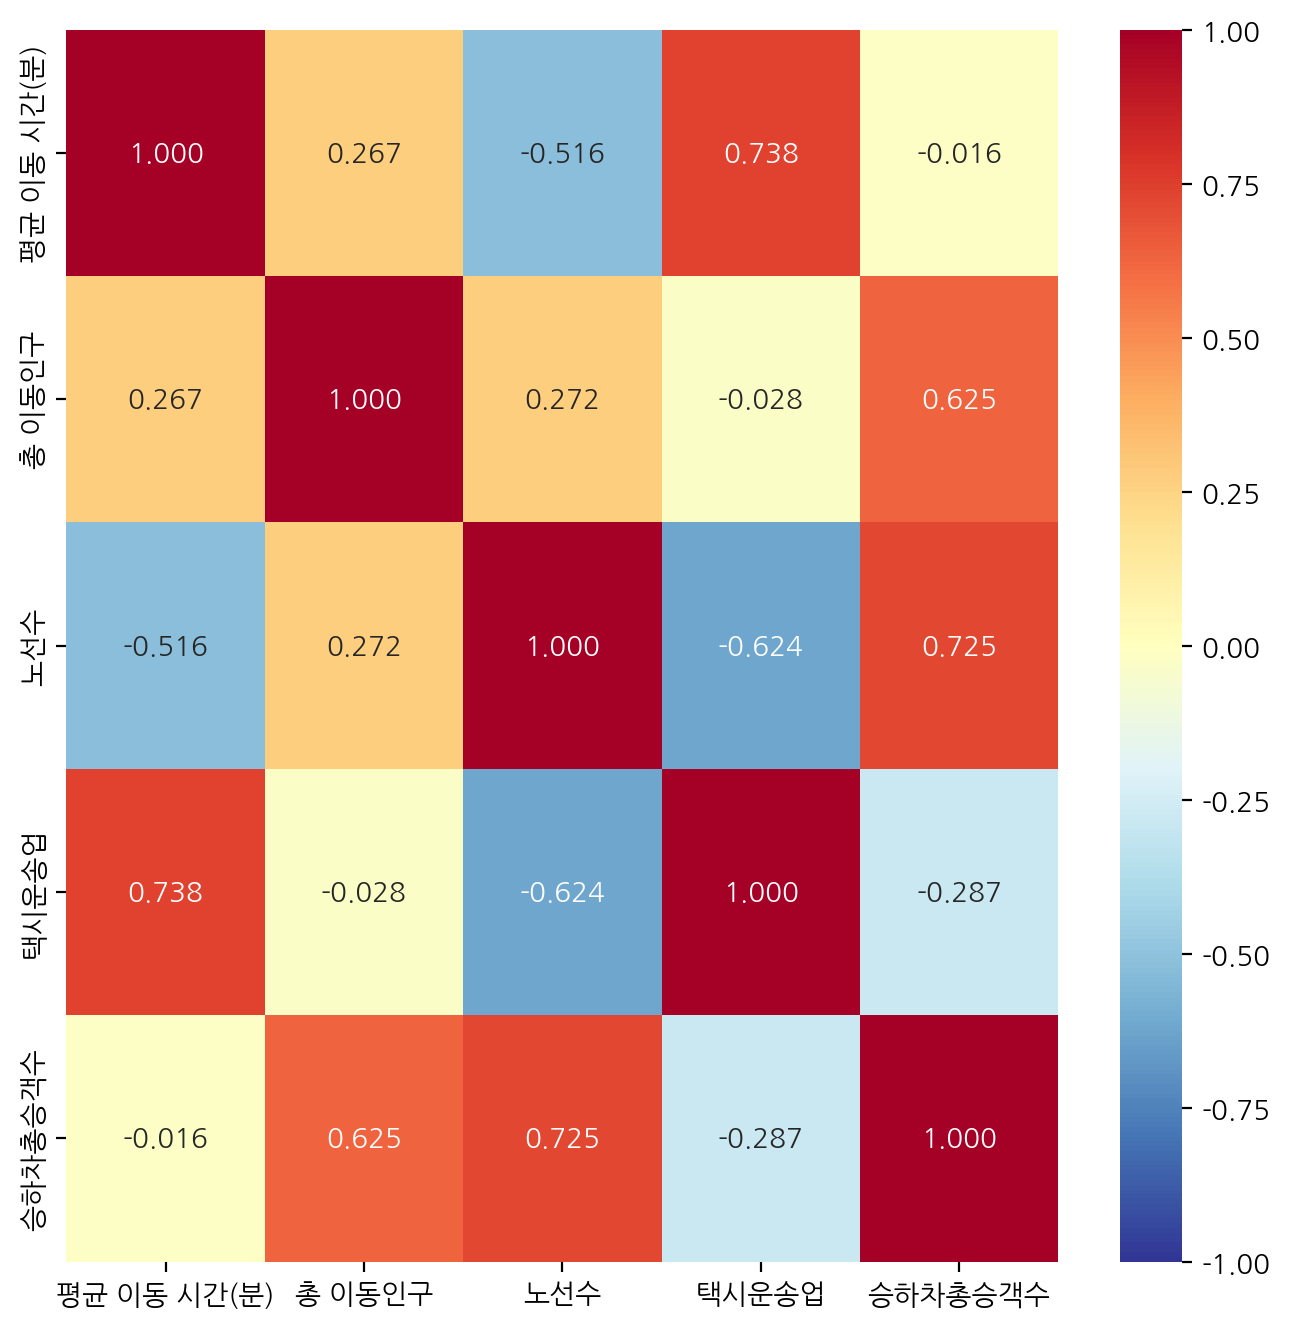

In [142]:
# 상관계수를 HeatMap으로 시각화
plt.figure(figsize = (8, 8))
sns.heatmap(df2.corr(), 
            annot = True,            # 숫자(상관계수) 표기 여부
            fmt = '.3f',             # 숫자 포멧 : 소수점 3자리까지 표기
            cmap = 'RdYlBu_r',       # 칼라맵
            vmin = -1, vmax = 1)     # 값의 최소, 최대값
plt.show()

### 중간요약
- 노선수와 인구합계는 음의 상관관계를 가지지만 P-value가 높다.
- 노선수와 승하차인구수는 강력한 양의 상관관계를 가지고 있다.
- 노선수와 음식점수는 약간의 양의 상관관계를 가지고 있다.

### 추가분석

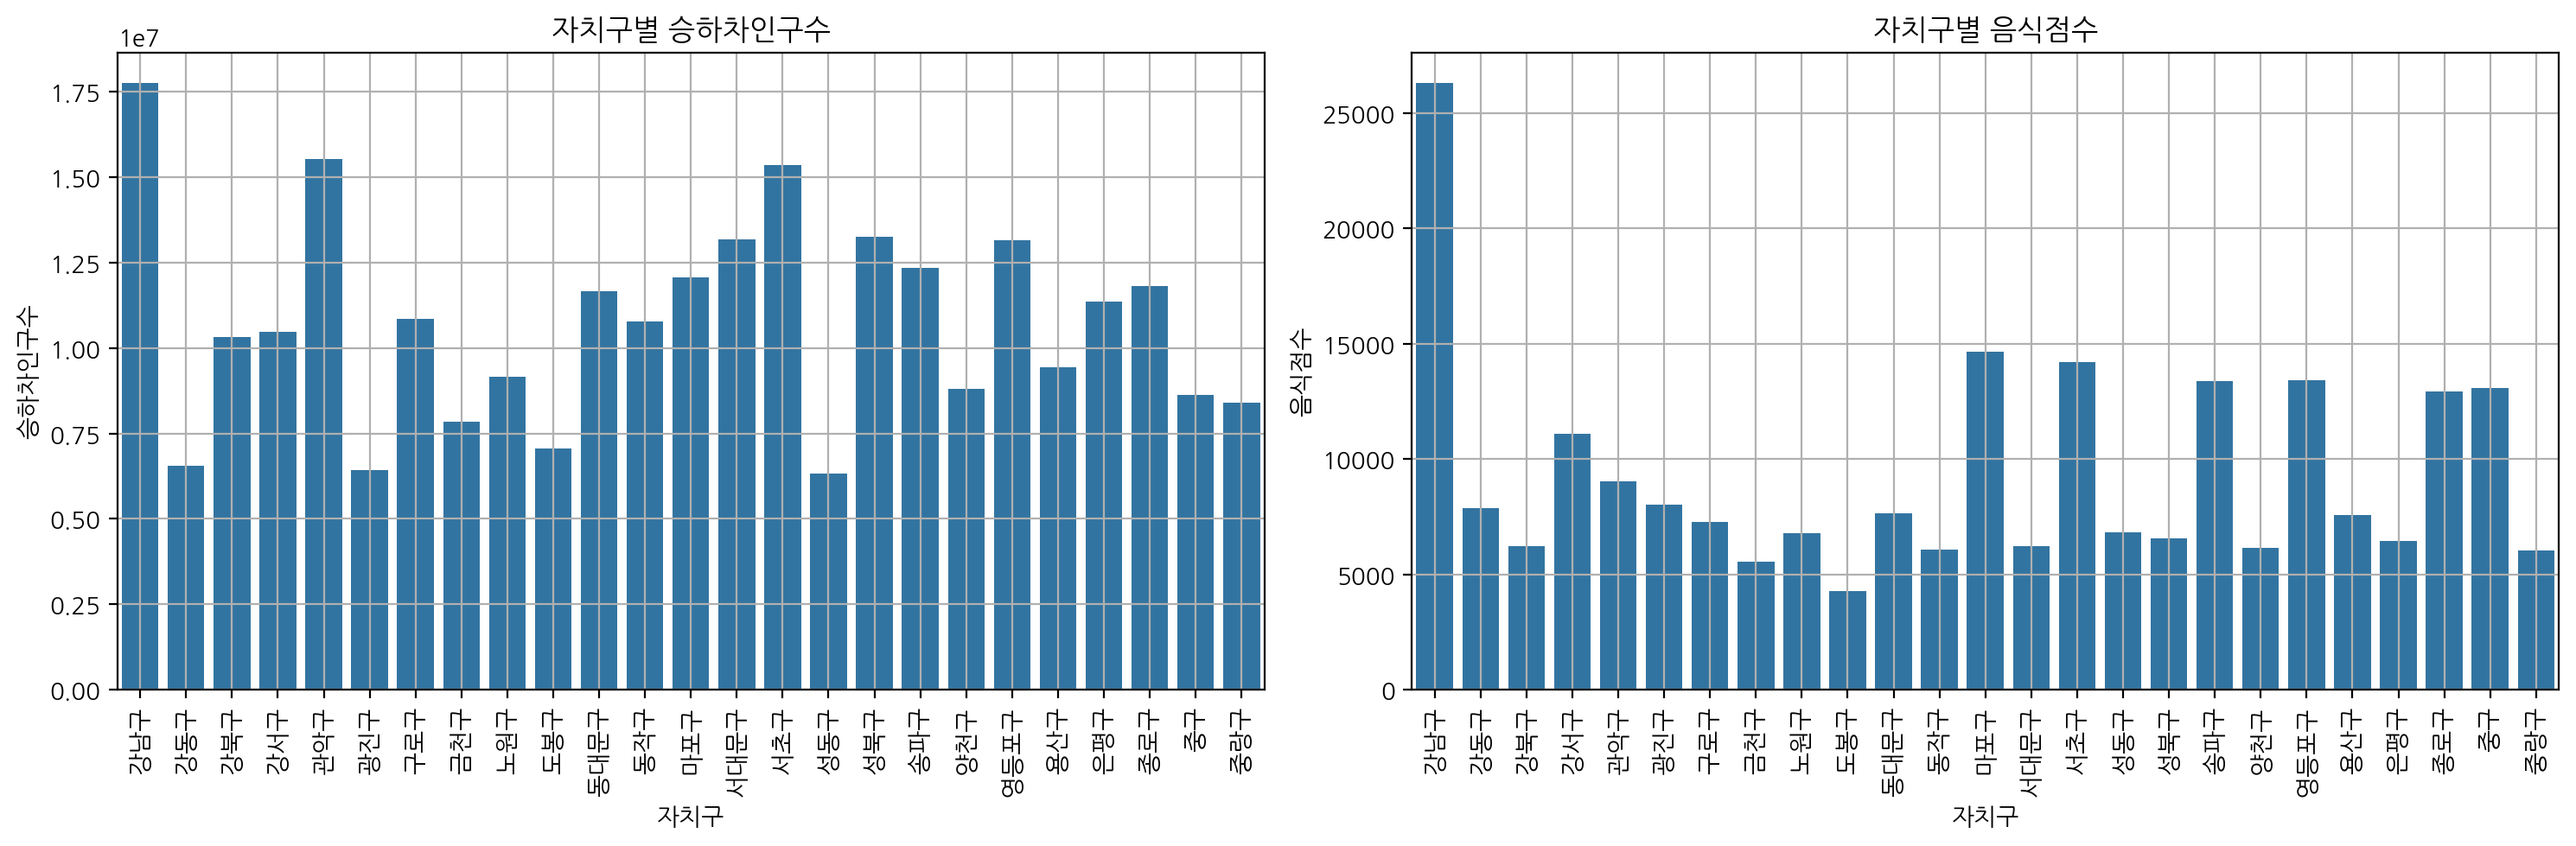

In [143]:
# 자치구별 승하차인구수, 음식점수 시각화
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.barplot(x='자치구', y='승하차인구수', data=df_1)
plt.xticks(rotation=90)
plt.title('자치구별 승하차인구수')
plt.grid()

plt.subplot(1, 2, 2)
sns.barplot(x='자치구', y='음식점수', data=df_1)
plt.xticks(rotation=90)
plt.title('자치구별 음식점수')
plt.grid()

plt.tight_layout()
plt.show()

In [144]:
df_1.sort_values(by='승하차인구수', ascending=False).head()

# 승하차인구수 top3 = 강남구, 관악구, 서초구
# 승하차인구수 lowest3 = 성동구, 광진구, 강동구
# 음식점수 top3 = 강남구, 마포구, 서초구 (영등포구, 송파구, 중구, 종로구)
# 음식점수 lowest3 = 도봉구, 금천구, 중랑구

,자치구,노선수,합계,승하차인구수,음식점수
0,강남구,99,562755,17753374,26295
4,관악구,82,497137,15541497,9038
14,서초구,105,412147,15352041,14202
16,성북구,100,436063,13253246,6570
13,서대문구,109,319403,13190553,6232


In [145]:
# 노선수 대비 승하차인구수가 많아 노선이 추가적으로 필요해 보이는 구 순위
df_1['diff'] = df_1['승하차인구수'] / df_1['노선수']
df_1['diff2'] = df_1['diff'] - df_1['diff'].mean()
df_1.loc[df_1['diff2'] > 0, ['자치구', 'diff2']].sort_values(by='diff2', ascending=False)

,자치구,diff2
1,강동구,124650.836996
17,송파구,50935.639415
3,강서구,45507.610144
4,관악구,41285.913215
0,강남구,31082.472097
24,중랑구,19517.041996
10,동대문구,7196.555329
18,양천구,6045.707610
8,노원구,1674.921012
5,광진구,1441.020135


In [146]:
# 노선수 대비 음식점수가 많아 노선이 추가적으로 필요해 보이는 구 순위
df_1['diff3'] = df_1['음식점수'] / df_1['노선수']
df_1['diff4'] = df_1['diff3'] - df_1['diff3'].mean()
df_1.loc[df_1['diff4'] > 0, ['자치구', 'diff4']].sort_values(by='diff4', ascending=False)

,자치구,diff4
1,강동구,196.862918
0,강남구,135.135645
17,송파구,85.368294
3,강서구,75.029584
5,광진구,55.645863
12,마포구,13.323702
14,서초구,4.786727
19,영등포구,2.311762


### 결과요약
- 중복된 구(강동구, 송파구, 강남구, 강서구, 광진구)에 노선을 추가해야 한다.

### 2) 평균이동시간이 길수록 인구대비 노선수는 적고 택시운송업 수는 많을 것이다. (노선수, 택시운송업 -> 평균이동시간)

In [147]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   평균 이동 시간(분)  25 non-null     float64
 1   총 이동인구       25 non-null     float64
 2   합계           25 non-null     int64  
 3   노선수          25 non-null     int64  
 4   택시운송업        25 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 KB


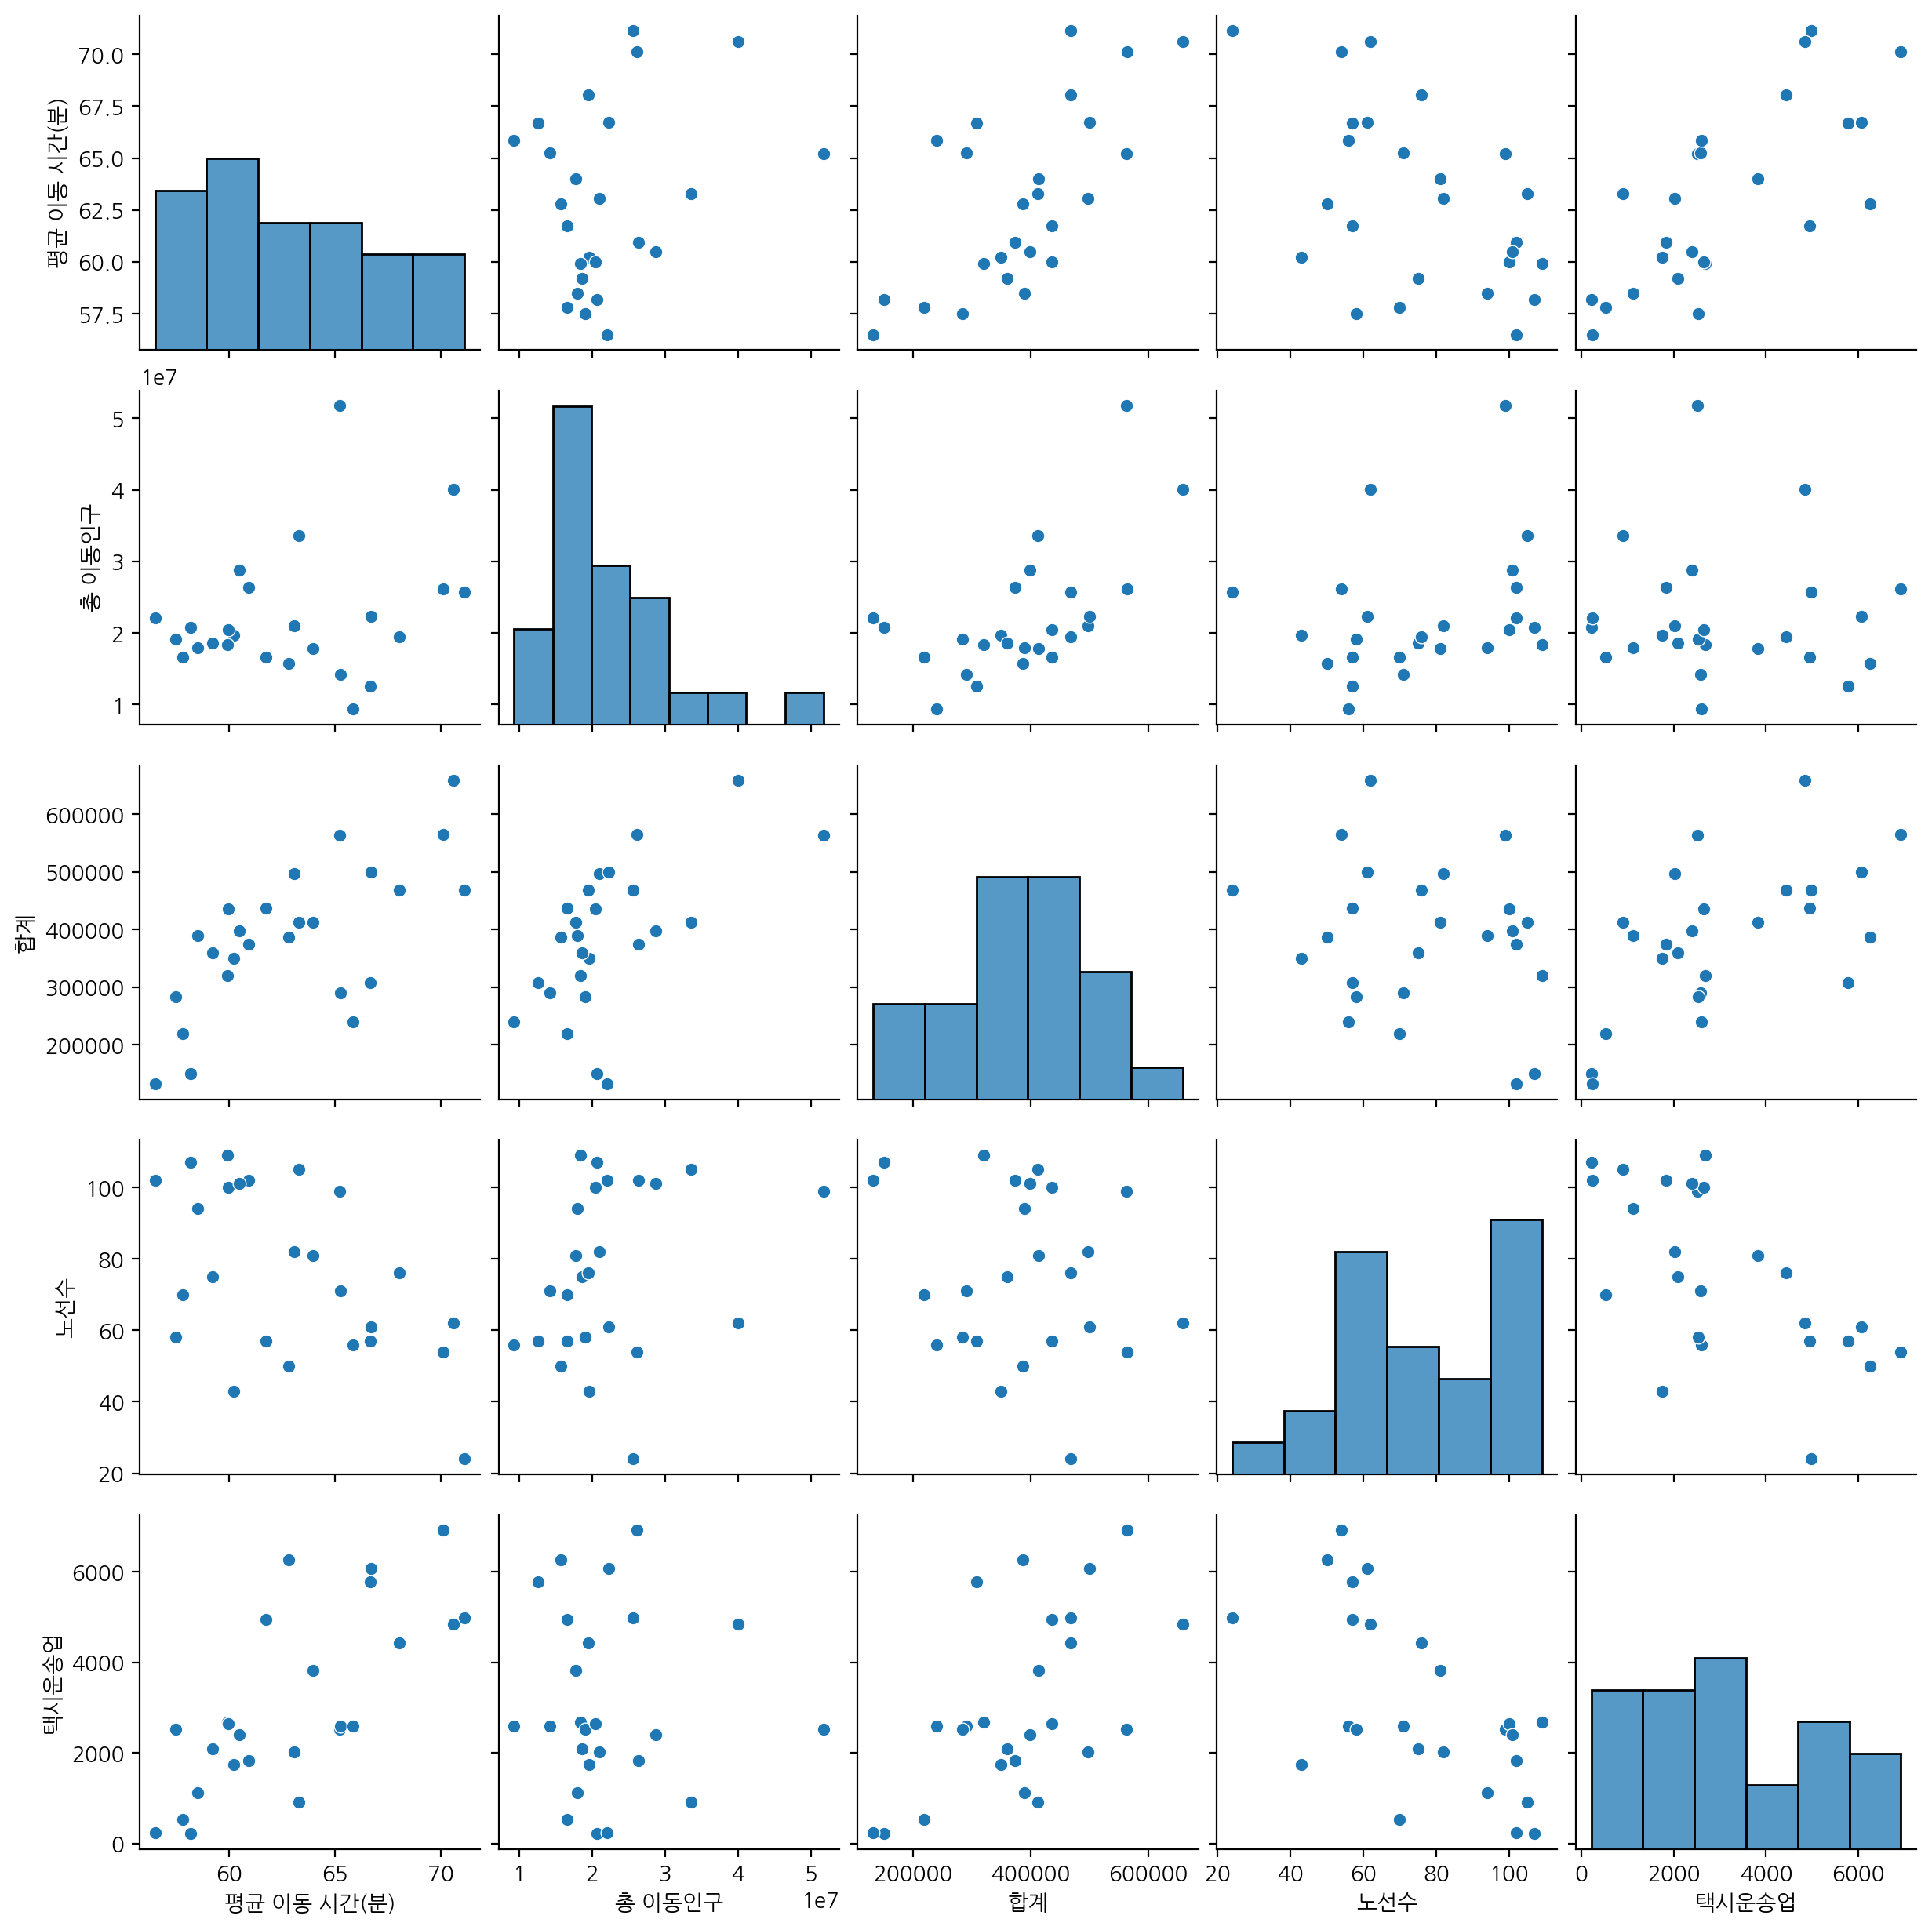

In [148]:
# 시각화
sns.pairplot(df_2)
plt.show()

In [149]:
df_2.corr(numeric_only=True)

,평균 이동 시간(분),총 이동인구,합계,노선수,택시운송업
평균 이동 시간(분),1.000000,0.267037,0.670733,-0.516482,0.737535
총 이동인구,0.267037,1.000000,0.587629,0.271757,-0.028218
합계,0.670733,0.587629,1.000000,-0.209958,0.584526
노선수,-0.516482,0.271757,-0.209958,1.000000,-0.623604
택시운송업,0.737535,-0.028218,0.584526,-0.623604,1.000000


In [150]:
# 상관계수와 p-value
print(spst.pearsonr(df_2['평균 이동 시간(분)'],df_2['합계']))
print(spst.pearsonr(df_2['평균 이동 시간(분)'],df_2['총 이동인구']))
print(spst.pearsonr(df_2['평균 이동 시간(분)'],df_2['노선수']))
print(spst.pearsonr(df_2['평균 이동 시간(분)'],df_2['택시운송업']))

PearsonRResult(statistic=0.670732759762401, pvalue=0.000243101541105834)
PearsonRResult(statistic=0.26703680923969225, pvalue=0.19690776223657205)
PearsonRResult(statistic=-0.5164817726116777, pvalue=0.008210977030339517)
PearsonRResult(statistic=0.737535464496498, pvalue=2.591434959926465e-05)


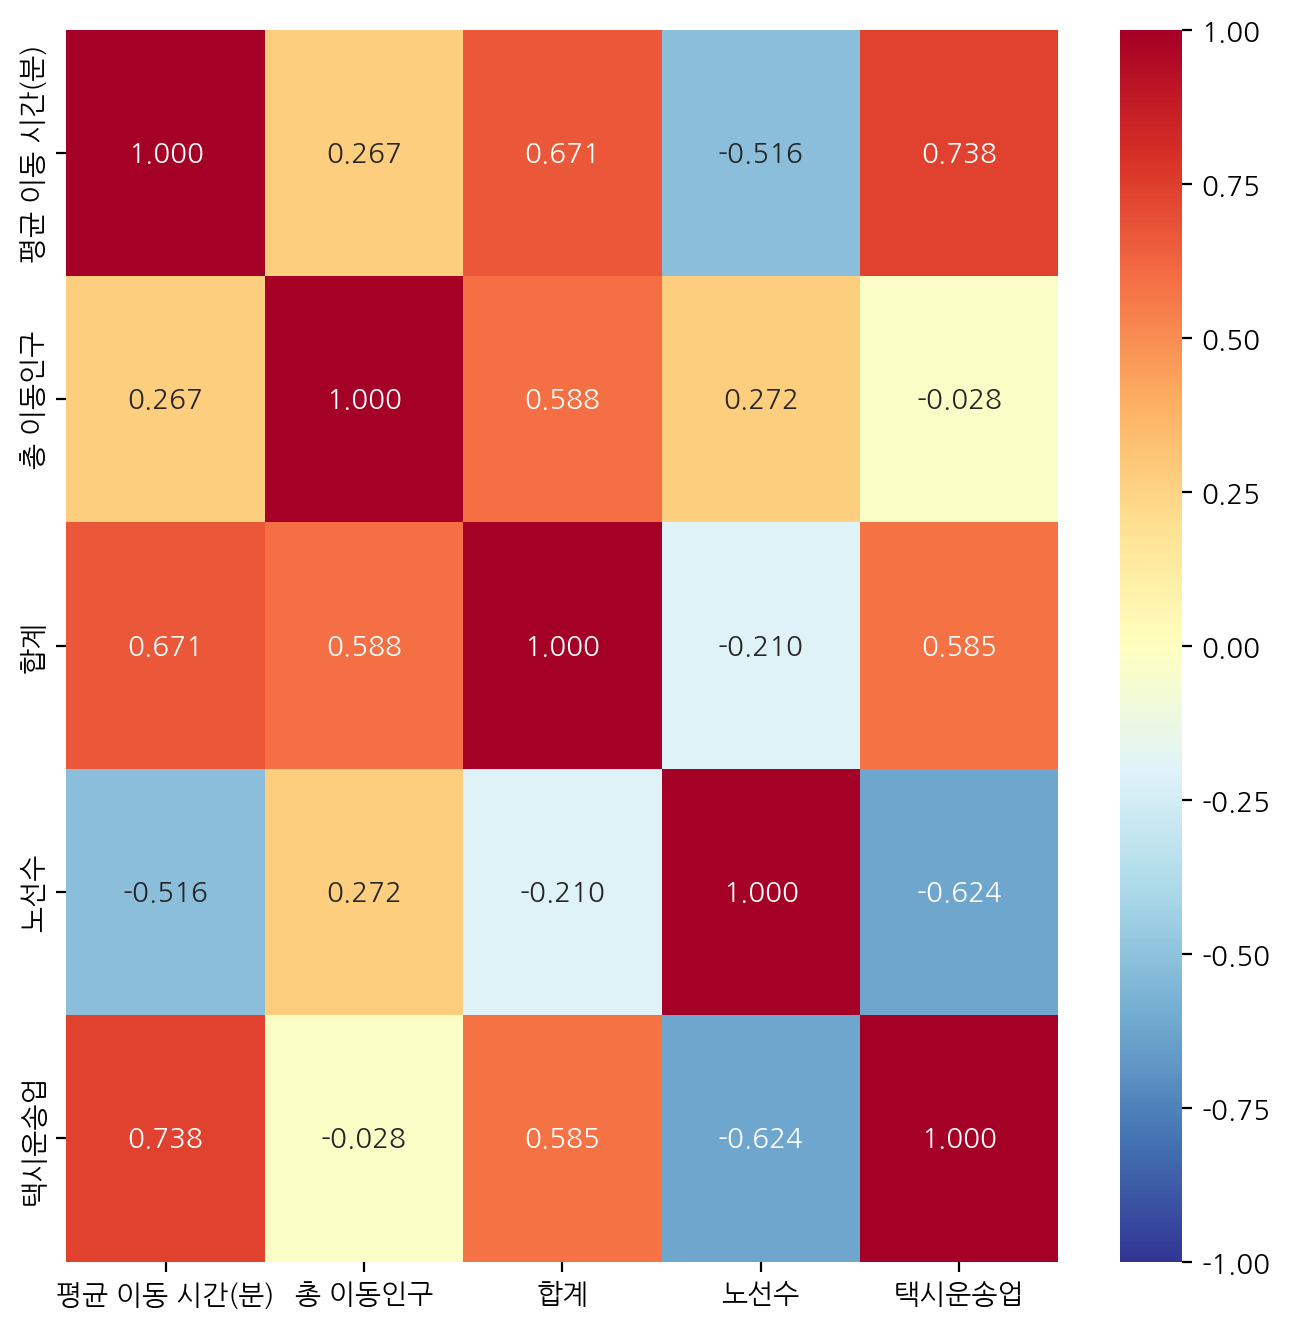

In [151]:
# 상관계수를 HeatMap으로 시각화
plt.figure(figsize = (8, 8))
sns.heatmap(df_2.corr(), 
            annot = True,            # 숫자(상관계수) 표기 여부
            fmt = '.3f',             # 숫자 포멧 : 소수점 3자리까지 표기
            cmap = 'RdYlBu_r',       # 칼라맵
            vmin = -1, vmax = 1)     # 값의 최소, 최대값
plt.show()

### 중간요약
- 평균 이동 시간(분)은 노선수와 음의 상관관계를 가진다.
- 평균 이동 시간(분)은 택시운송업수, 합계(인구)와 양의 상관관계를 가진다.
- 평균 이동 시간(분)이랑 총 이동인구와 상관관계가 없다.

### 추가분석

In [157]:
# 노선수와 택시운송업 상관관계 분석
print(spst.pearsonr(df_2['노선수'],df_2['택시운송업']))

PearsonRResult(statistic=-0.6236041299384008, pvalue=0.0008664168232065649)


In [163]:
# 평균 이동 시간(분)이 높은 자치구 순위
df_2[['자치구','평균 이동 시간(분)']].sort_values(by='평균 이동 시간(분)', ascending=False).head(10)

,자치구,평균 이동 시간(분)
1,강동구,71.135695
17,송파구,70.606433
3,강서구,70.107829
21,은평구,68.036441
8,노원구,66.705984
9,도봉구,66.683308
7,금천구,65.848807
2,강북구,65.258796
0,강남구,65.220874
6,구로구,63.983186


In [164]:
# 노선수 대비 총 이동인구수가 평균보다 높은 지역구 순위
df_2['diff'] = df_2['총 이동인구'] / df_2['노선수']
df_2['diff2'] = df_2['diff'] - df_2['diff'].mean()
df_2.loc[df_2['diff2'] > 0, ['자치구', 'diff2']].sort_values(by='diff2', ascending=False)

,자치구,diff2
1,강동구,744521.875701
17,송파구,321436.165741
0,강남구,198059.586572
3,강서구,159198.000192
5,광진구,132194.030962
8,노원구,40121.428549
15,성동구,4133.188934


In [165]:
# 합계(인구) 대비 택시운송업수가 많은 자치구 순위
df_2['diff3'] = df_2['합계'] / df_2['택시운송업']
df_2['diff4'] = df_2['diff3'] - df_2['diff3ㅠ'].mean()
df_2.loc[df_2['diff4'] > 0, ['자치구', 'diff4']].sort_values(by='diff4', ascending=False)

,자치구,diff4
22,종로구,493.715794
23,중구,356.504809
14,서초구,252.256436
20,용산구,214.236341
11,동작구,144.718338
4,관악구,41.094247
0,강남구,19.418369


In [178]:
# 데이터 표준화
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_4 = df_2[['평균 이동 시간(분)', 'diff2', 'diff4']]
df_4 = scaler.fit_transform(df_4)
df_4 = pd.DataFrame(df_4)
df_4 = pd.concat([df_2['자치구'], df_4], axis=1)
df_4.head()

,자치구,0,1,2
0,강남구,0.595990,0.394849,0.264264
1,강동구,1.000000,1.000000,0.063187
2,강북구,0.598580,0.037288,0.091092
3,강서구,0.929792,0.351814,0.043942
4,관악구,0.448702,0.099711,0.297888


In [183]:
# 표준화한 값을 합하여 내림차순 정리
df_4['합'] = df_4.sum(axis=1, numeric_only=True)
df_4.sort_values(by='합', ascending=False).head()

,자치구,0,1,2,합
1,강동구,1.000000,1.000000,0.063187,4.126374
17,송파구,0.963849,0.531476,0.128009,3.246669
3,강서구,0.929792,0.351814,0.043942,2.651095
14,서초구,0.463697,0.170157,0.625445,2.518599
0,강남구,0.595990,0.394849,0.264264,2.510205


### 결과요약
- 평균 이동 시간(분)이 긴 자치구 중에서 총 이동인구 대비 노선수가 적고 합계(인구) 대비 택시운송업수가 많은 자치구인 강남구에 노선을 추가해야 한다.
- 이를 표준화하여 총합이 큰 값을 기준으로 상위 5개 구(강동구, 송파구, 강서구, 서초구, 강남구)에 노선을 추가하여야 한다.

# 6. 관계 정리

### 1) 강한 관계의 열

- 노선수, 승하차인구수
- 평균 이동 시간(분),택시운송업

### 2) 중간 관계의 열

- 노선수, 음식점수
- 노선수와 평균 이동시간(분)

# 7. 솔루션 도출

- 위에서 확인된 내용을 기초로하여 노선(또는 정류장) 추가를 제안할 자치구를 확인하세요. 

### 결론1: 어느 구에 버스 노선 또는 정류장이 제일 필요한가요?

- 가정 1번에 의하면 강동구, 송파구, 강남구, 강서구, 광진구에 추가 버스 노선이 필요하다.
- 가정 2번에 의하면 강동구, 송파구, 강서구, 서초구, 강남구에 추가 버스 노선이 필요하다.

### 결론2: 그 이유는 무엇인가요?

- 가정 1번에서의 상관관계분석에 의하면 노선수와 승하차인구수, 음식점수는 양의 상관관계를 가지고 있다.
- 노선수 대비 승하차인구수가 많은 구와 음식점수가 많은 구를 포괄하여 5개의 노선을 선정

- 가정 2번에서의 상관관계분석에 의하면 평균 이동 시간(분)과 택시운송업은 양의 상관관계, 평균 이동 시간(분)과 노선수는 음의 상관관계를 가지고 있다.
- 평균 이동시간(분), 노선수 대비 총 이동인구, 합계(인구) 대비 택시운송업수를 산정하여 이를 표준화하고 이를 더한 값 중에서 상위 5개의 노선을 선정